<a href="https://colab.research.google.com/github/Springboard429/B12---PlantDocBot-AI-Plant-Disease-Diagnosis-via-Chat-and-Image-Upload/blob/Sneha_John/Plantdoc2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_path = '/content/archive.zip'
extract_path = '/content/dataset'

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipping completed successfully!")


Unzipping completed successfully!


Libraries Used

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
from collections import Counter
from torch.nn import CrossEntropyLoss

In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

Define Transformation piplelines

Train transforms(with augmentation)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

Val transforms(no agumentation)

In [ ]:
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])])

Load Datasets Using ImageFolder



Printing Dataset Information(Train)

In [ ]:
train_data_root = '/content/dataset/PlantVillage/train'
train_dataset = datasets.ImageFolder(
    root=train_data_root,
    transform=train_transform
)
print(f"Train dataset loaded from: {train_data_root}")
print(f"Classes: {len(train_dataset.classes)}")
print(f"Samples: {len(train_dataset)}")
print(f"Class-to-index: {train_dataset.class_to_idx}")

Train dataset loaded from: /content/dataset/PlantVillage/train
Classes: 38
Samples: 43444
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___hea

Printing Dataset Information(Val)

In [ ]:
val_data_root = '/content/dataset/PlantVillage/val'
val_dataset = datasets.ImageFolder(
    root=val_data_root,
    transform=val_transform
)
print(f"Val dataset loaded from:{val_data_root}")
print(f"Classes: {len(val_dataset.classes)}")
print(f"Samples: {len(val_dataset)}")
print(f"Class-to-index: {val_dataset.class_to_idx}")

Val dataset loaded from:/content/dataset/PlantVillage/val
Classes: 38
Samples: 10861
Class-to-index: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy'

Verifying Class Structure Consistency

In [ ]:
if train_dataset.classes == val_dataset.classes:
    print("Train and val datasets have identical class structure")
    num_classes = len(train_dataset.classes)
    class_names = train_dataset.classes
else:
    print("Warning: Train and val classes differ!")
    print(f"Train classes: {train_dataset.classes}")
    print(f"Val classes: {val_dataset.classes}")

Train and val datasets have identical class structure


Create Data Loaders

Data Loader(Train)

In [ ]:
BATCH_SIZE = 32
NUM_WORKERS = 2

# Train DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Train loader:{len(train_loader)} batches")


Train loader:1358 batches


Data Loader(Val)

In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print(f"Val loader:{len(val_loader)} batches")

Val loader:340 batches


Handle Class Imbalance

In [ ]:
# Extract labels from training dataset
train_labels = [label for _, label in train_dataset]
# Count samples per class
class_counts = Counter(train_labels)
# Total samples
total_samples = sum(class_counts.values())
# Compute class weights
class_weights = [
    total_samples / (len(class_counts) * class_counts[i])
    for i in range(len(class_counts))
]
class_weights = torch.tensor(class_weights, dtype=torch.float)
print("Class weights:", class_weights)
# Loss function with class weights
criterion = CrossEntropyLoss(weight=class_weights.to(device))

Class weights: tensor([2.2684, 2.3050, 5.1967, 0.8687, 0.9511, 1.3578, 1.6714, 2.7884, 1.1996,
        1.4508, 1.2306, 1.2111, 1.0328, 1.3278, 3.3725, 0.2595, 0.6220, 3.9697,
        1.4345, 0.9664, 1.4291, 1.4291, 9.4485, 3.8494, 0.2808, 0.7788, 1.2889,
        3.1408, 0.6717, 1.4291, 0.7487, 1.5023, 0.8068, 0.8525, 1.0180, 0.2667,
        3.8236, 0.8981])


Verify Preprocessing Pipeline

In [ ]:
# Verify Preprocessing Pipeline
# Check batch shapes and data flow

train_batch_images, train_batch_labels = next(iter(train_loader))
val_batch_images, val_batch_labels = next(iter(val_loader))

print("TRAIN BATCH:")
print(f" Images shape: {train_batch_images.shape}")
print(f" Labels shape: {train_batch_labels.shape}")
print(f" Images dtype: {train_batch_images.dtype}")
print(f" Value range: [{train_batch_images.min():.3f}, {train_batch_images.max():.3f}]")

print("\nVAL BATCH:")
print(f" Images shape: {val_batch_images.shape}")
print(f" Labels shape: {val_batch_labels.shape}")
print(f" Images dtype: {val_batch_images.dtype}")
print(f" Value range: [{val_batch_images.min():.3f}, {val_batch_images.max():.3f}]")

print("\nPipeline working correctly!"
      if train_batch_images.shape[0] == BATCH_SIZE else "Check pipeline")


TRAIN BATCH:
 Images shape: torch.Size([32, 3, 224, 224])
 Labels shape: torch.Size([32])
 Images dtype: torch.float32
 Value range: [-2.118, 2.640]

VAL BATCH:
 Images shape: torch.Size([32, 3, 224, 224])
 Labels shape: torch.Size([32])
 Images dtype: torch.float32
 Value range: [-2.101, 2.640]

Pipeline working correctly!


Vizualize Data Augmentation Effect

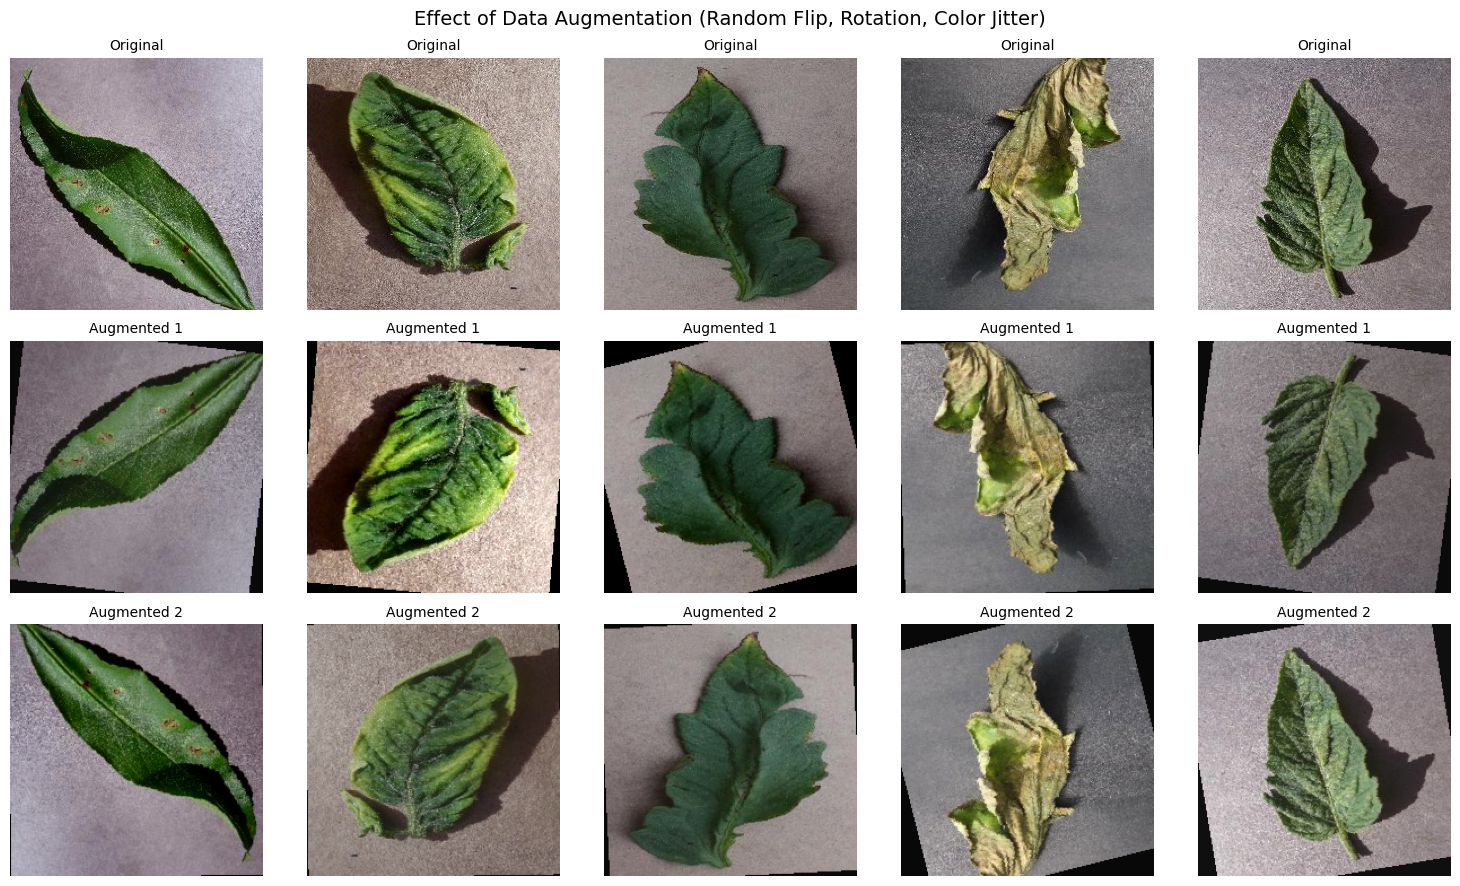

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Define mean and std for denormalization based on the transforms used
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Extract image paths from the train_dataset
train_image_paths = [s[0] for s in train_dataset.samples]

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

np.random.seed(42)
sample_indices = np.random.choice(len(train_image_paths), 5, replace=False)

for col, idx in enumerate(sample_indices):
    img_path = train_image_paths[idx]
    original_img = Image.open(img_path)

    axes[0, col].imshow(original_img)
    axes[0, col].set_title("Original", fontsize=10)
    axes[0, col].axis("off")

    aug1 = train_transform(original_img)
    aug1_display = denormalize(aug1.clone(), mean, std).permute(1, 2, 0).numpy()
    axes[1, col].imshow(aug1_display)
    axes[1, col].set_title("Augmented 1", fontsize=10)
    axes[1, col].axis("off")

    aug2 = train_transform(original_img)
    aug2_display = denormalize(aug2.clone(), mean, std).permute(1, 2, 0).numpy()
    axes[2, col].imshow(aug2_display)
    axes[2, col].set_title("Augmented 2", fontsize=10)
    axes[2, col].axis("off")

plt.suptitle("Effect of Data Augmentation (Random Flip, Rotation, Color Jitter)", fontsize=14)
plt.tight_layout()
plt.show()

Sample Batches from Train and Val

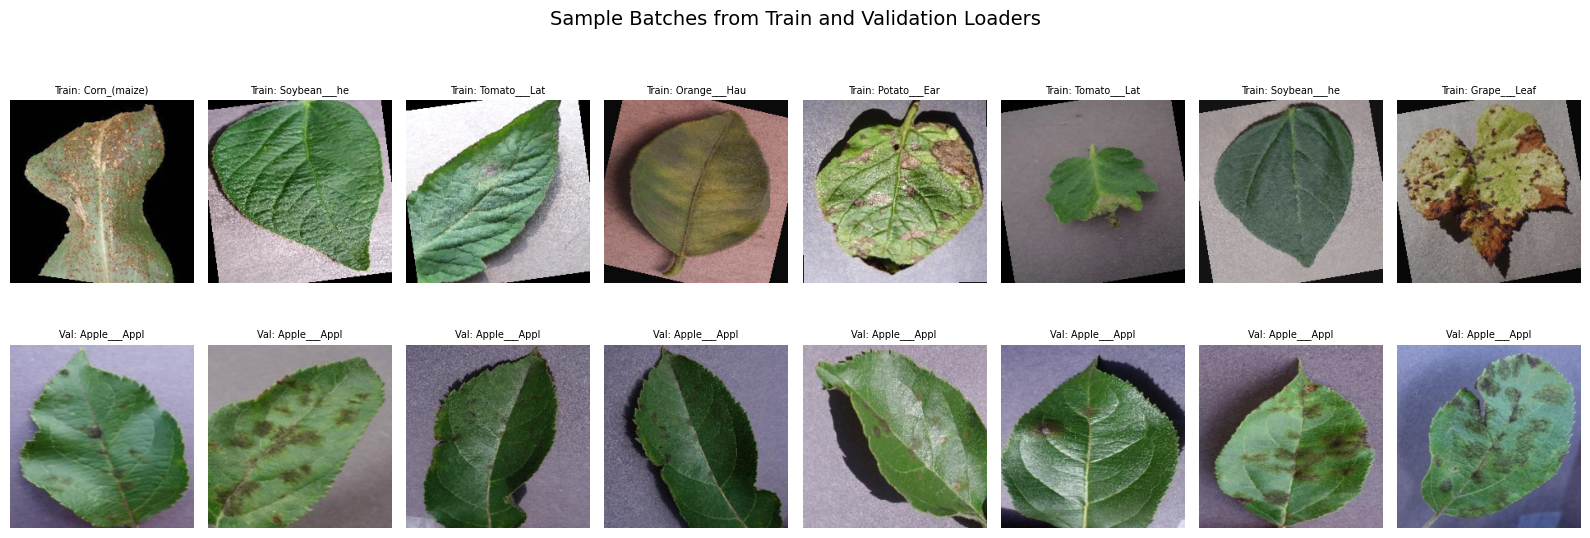

In [ ]:
fig, axes = plt.subplots(2, 8, figsize=(16, 6))

train_images, train_labels_batch = next(iter(train_loader))
for i in range(8):
    img = denormalize(train_images[i].clone(), mean, std).permute(1, 2, 0).numpy()
    label_id = train_labels_batch[i].item()
    label_name = class_names[label_id]

    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Train: {label_name[:12]}", fontsize=7)
    axes[0, i].axis("off")

val_images, val_labels_batch = next(iter(val_loader))
for i in range(8):
    img = denormalize(val_images[i].clone(), mean, std).permute(1, 2, 0).numpy()
    label_id = val_labels_batch[i].item()
    label_name = class_names[label_id]

    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Val: {label_name[:12]}", fontsize=7)
    axes[1, i].axis("off")

plt.suptitle("Sample Batches from Train and Validation Loaders", fontsize=14)
plt.tight_layout()
plt.show()
